Scanning dataset... this may take a moment.
Processed 500 images.

Displaying Results...


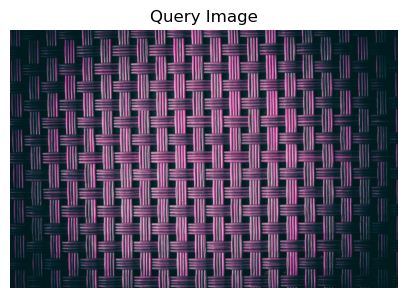

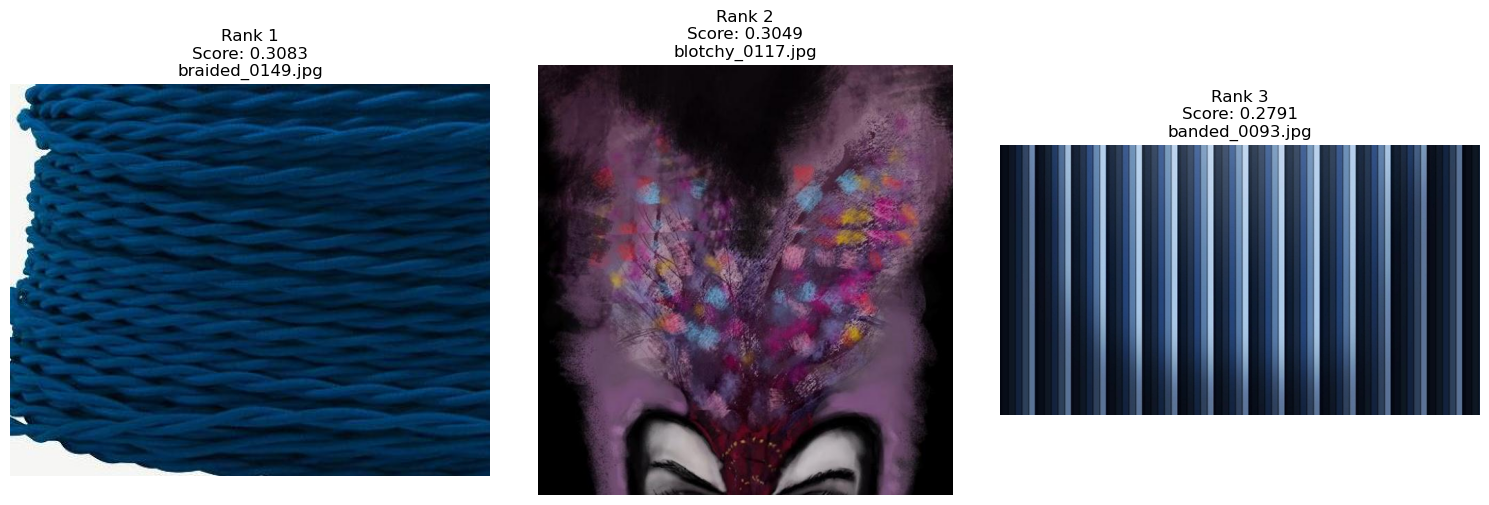

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import os

# --- CONFIGURATION ---
# Change these paths to match your extracted dataset location
extract_to_path = r"C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\ext dataset"
query_path = r"C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\fabric-texture-1100x733.jpg"

# Function to extract a color histogram from an image in HSV color space
def extract_color_histogram(image, bins=(8, 8, 8)):
    # Convert BGR to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Compute 3D histogram
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    # Normalize
    cv2.normalize(hist, hist)
    return hist.flatten()

# 1. Load query image
img = cv2.imread(query_path)

if img is None:
    print(f"Error: Could not find query image at {query_path}")
else:
    # Resize query for consistent comparison
    img_resized = cv2.resize(img, (256, 256))
    query_features = extract_color_histogram(img_resized)

    # 2. Automatically find images in the extracted dataset folder
    dataset_images = []
    dataset_features = []
    file_names = []

    print("Scanning dataset... this may take a moment.")
    
    # Limit processing to avoid memory issues (optional)
    MAX_IMAGES = 500 

    for root, dirs, files in os.walk(extract_to_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')) and not file.startswith('._'):
                path = os.path.join(root, file)
                temp_img = cv2.imread(path)
                
                if temp_img is not None:
                    # Resize to keep memory usage low and processing fast
                    temp_resized = cv2.resize(temp_img, (256, 256))
                    feat = extract_color_histogram(temp_resized)
                    
                    dataset_images.append(temp_img) # Storing original for display
                    dataset_features.append(feat)
                    file_names.append(file)
                
                if len(dataset_features) >= MAX_IMAGES:
                    break
        if len(dataset_features) >= MAX_IMAGES:
            break

    print(f"Processed {len(dataset_features)} images.")

    # 4. Compute cosine similarity
    # We reshape query_features to (1, -1) as required by sklearn
    similarities = [cosine_similarity([query_features], [feat])[0][0] for feat in dataset_features]

    # 5. Rank images based on similarity score (descending)
    ranked_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)

    # 6. Visualization
    print("\nDisplaying Results...")

    # Display Query Image
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Query Image')
    plt.axis('off')
    plt.show()

    # Display Top Matches
    top_k = min(3, len(dataset_features))
    if top_k > 0:
        fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
        if top_k == 1: axes = [axes]

        for i in range(top_k):
            idx = ranked_indices[i]
            similar_img = dataset_images[idx]
            score = similarities[idx]
            name = file_names[idx]

            axes[i].imshow(cv2.cvtColor(similar_img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(f"Rank {i+1}\nScore: {score:.4f}\n{name}")
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No images found in the dataset folder to compare.")